# Analyse quotidienne des athlètes

Ce notebook présente la fusion des données Fitbit, PMSYS, Google Docs et nutrition, le prétraitement, l'indice de performance et les cibles de modélisation.

Les scripts Python sont numérotés selon l'ordre de traitement : `1_nutrition.py`, `2_merge_dataset.py`, `3_features.py`, `4_train_model.py`, puis `5_eda.py` pour l'analyse exploratoire. `src/run_pipeline.py` exécute automatiquement les quatre premières étapes. `meal_clustering.py` est un script autonome.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'p01': '#1565C0', 'p03': '#00897B', 'p05': '#EF6C00'}
DATA_DIR = Path('..') / 'data' / 'processed'
df = pd.read_csv(DATA_DIR / 'test_dataset.csv', parse_dates=['date'])
df.head()

,participant_id,date,num_meals,total_calories_consumed,meal_types,image_names,calories_burned,distance,steps,heart_rate_mean,...,sleep_hours_7d_avg,training_load_7d_avg,readiness_7d_avg,training_load_7d_sum,training_load_28d_avg,acwr,injury_event,injury_next_7d,performance_index,performance_index_next_day
0,p01,2019-11-01,5.0,2544.0,NaN,NaN,4009.10,1442400.0,17873.0,0.0,...,5.841667,280.0,5.000000,280.0,280.0,0.142857,0,0,58.33,60.00
1,p01,2019-11-02,5.0,2544.0,NaN,NaN,3533.56,1058480.0,13118.0,0.0,...,6.070833,280.0,5.500000,560.0,280.0,0.285714,0,0,60.00,54.17
2,p01,2019-11-03,5.0,2544.0,NaN,NaN,3748.73,1146085.0,14312.0,0.0,...,6.147222,280.0,6.166667,840.0,280.0,0.428571,0,0,54.17,54.17
3,p01,2019-11-04,5.0,2544.0,NaN,NaN,3353.38,885970.0,10970.0,0.0,...,6.114583,280.0,6.500000,1120.0,280.0,0.571429,0,0,54.17,50.00
4,p01,2019-11-05,5.0,2544.0,NaN,NaN,3794.63,1371470.0,16186.0,0.0,...,5.978333,266.0,6.700000,1330.0,266.0,0.714286,0,0,50.00,50.00


## Structure et valeurs manquantes

Dimensions : (456, 74)


float64           38
int64             32
str                3
datetime64[us]     1
Name: count, dtype: int64

,missing_percent
meal_types,65.4
image_names,65.4
performance_index_next_day,0.7


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
participant_id,456,3,p01,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,456,NaN,NaN,NaN,2020-01-15 12:00:00,2019-11-01 00:00:00,2019-12-08 18:00:00,2020-01-15 12:00:00,2020-02-22 06:00:00,2020-03-31 00:00:00,NaN
num_meals,456.0,NaN,NaN,NaN,3.524123,1.0,2.0,3.0,5.0,9.5,1.767991
total_calories_consumed,456.0,NaN,NaN,NaN,1654.298246,163.0,1054.0,1133.0,2544.0,4779.0,890.206445
meal_types,158,24,"Petit-déjeuner, Déjeuner, Collation / Encas, D...",19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_names,158,158,"IMG_8916.jpeg, IMG_8917.jpeg, IMG_8918.jpeg, I...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories_burned,456.0,NaN,NaN,NaN,3168.261571,1929.6,2725.245,3271.085,3672.0175,5092.17625,723.086884
distance,456.0,NaN,NaN,NaN,763735.039474,0.0,485405.0,778850.0,1000320.0,1772692.5,392567.156511
steps,456.0,NaN,NaN,NaN,9825.166118,0.0,6280.0,10116.5,13115.75,23369.375,4975.129915
heart_rate_mean,456.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


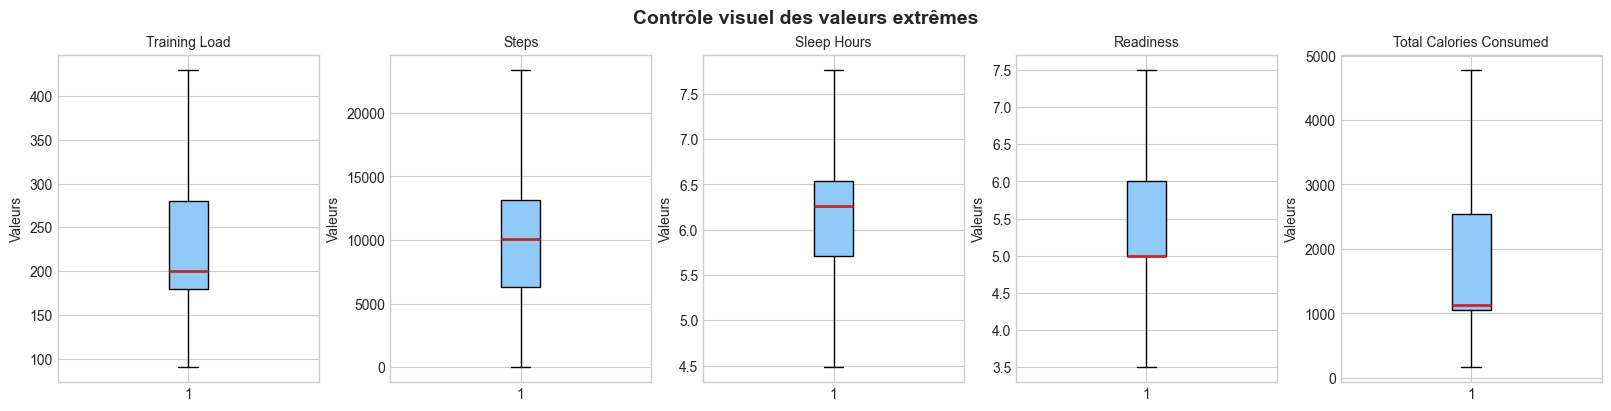

In [4]:
print('Dimensions :', df.shape) # (nb tuples, Attributs)

display(df.dtypes.value_counts())
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
display(missing[missing > 0].head(15).to_frame('missing_percent'))
display(df.describe(include='all').T.head(20))

numeric_to_check = [column for column in ['training_load', 'steps', 'sleep_hours', 'readiness', 'total_calories_consumed'] if column in df]
fig, axes = plt.subplots(1, len(numeric_to_check), figsize=(16, 4), constrained_layout=True)
for axis, column in zip(axes, numeric_to_check):
    axis.boxplot(df[column].dropna(), patch_artist=True,
                 boxprops={'facecolor': '#90CAF9'}, medianprops={'color': '#C62828', 'linewidth': 2})
    axis.set_title(column.replace('_', ' ').title(), fontsize=10)
    axis.set_ylabel('Valeurs')
fig.suptitle('Contrôle visuel des valeurs extrêmes', fontsize=14, fontweight='bold')
plt.show()

## Indice de performance et risque de blessure

L'indice `performance_index` est une moyenne bornée entre 0 et 100 de la readiness, de la qualité et durée du sommeil, de l'humeur, de la fatigue et des douleurs musculaires.

La cible `injury_next_7d` vaut 1 si une blessure est observée dans les sept jours suivant la date courante.

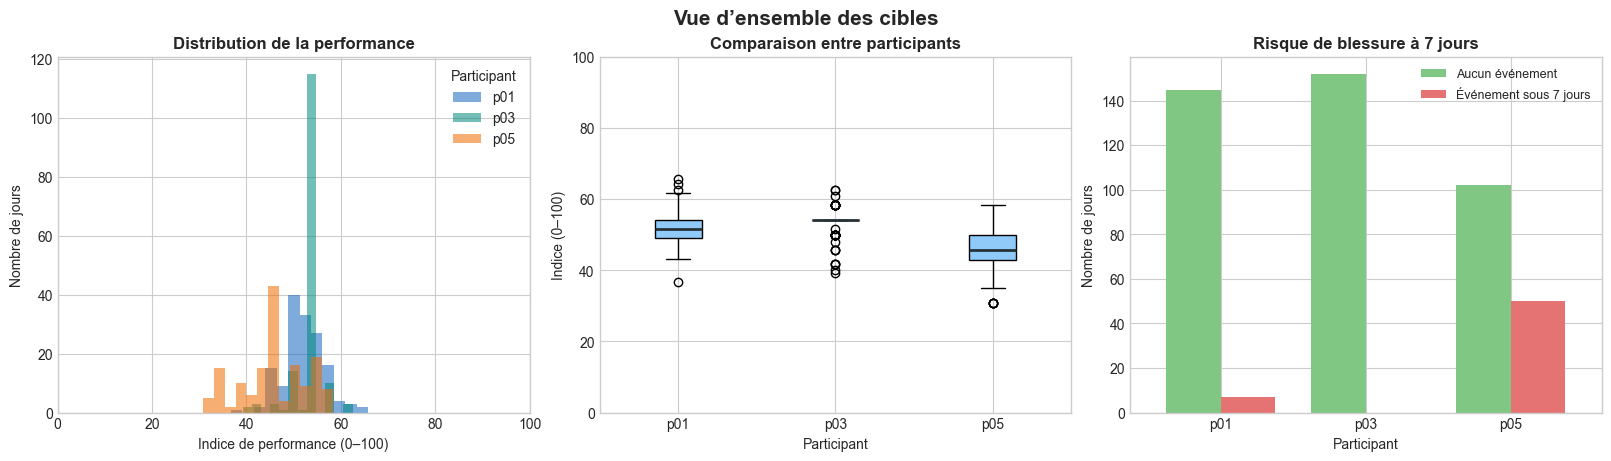

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for participant_id, group in df.groupby('participant_id'):
    axes[0].hist(group['performance_index'], bins=12, alpha=0.55,
                 color=COLORS.get(participant_id, '#455A64'), label=participant_id)
axes[0].set_title('Distribution de la performance', fontweight='bold')
axes[0].set_xlabel('Indice de performance (0–100)')
axes[0].set_ylabel('Nombre de jours')
axes[0].legend(title='Participant', frameon=False)
axes[0].set_xlim(0, 100)

box_data = [df.loc[df['participant_id'] == participant_id, 'performance_index']
            for participant_id in sorted(df['participant_id'].unique())]
axes[1].boxplot(box_data, tick_labels=sorted(df['participant_id'].unique()), patch_artist=True,
                boxprops={'facecolor': '#90CAF9'}, medianprops={'color': '#263238', 'linewidth': 2})
axes[1].set_title('Comparaison entre participants', fontweight='bold')
axes[1].set_xlabel('Participant')
axes[1].set_ylabel('Indice (0–100)')
axes[1].set_ylim(0, 100)

risk_counts = df.groupby(['participant_id', 'injury_next_7d']).size().unstack(fill_value=0)
risk_counts.rename(columns={0: 'Aucun événement', 1: 'Événement sous 7 jours'}).plot(
    kind='bar', ax=axes[2], color=['#81C784', '#E57373'], width=0.75)
axes[2].set_title('Risque de blessure à 7 jours', fontweight='bold')
axes[2].set_xlabel('Participant')
axes[2].set_ylabel('Nombre de jours')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(frameon=False, fontsize=9)

fig.suptitle('Vue d’ensemble des cibles', fontsize=15, fontweight='bold')
plt.show()

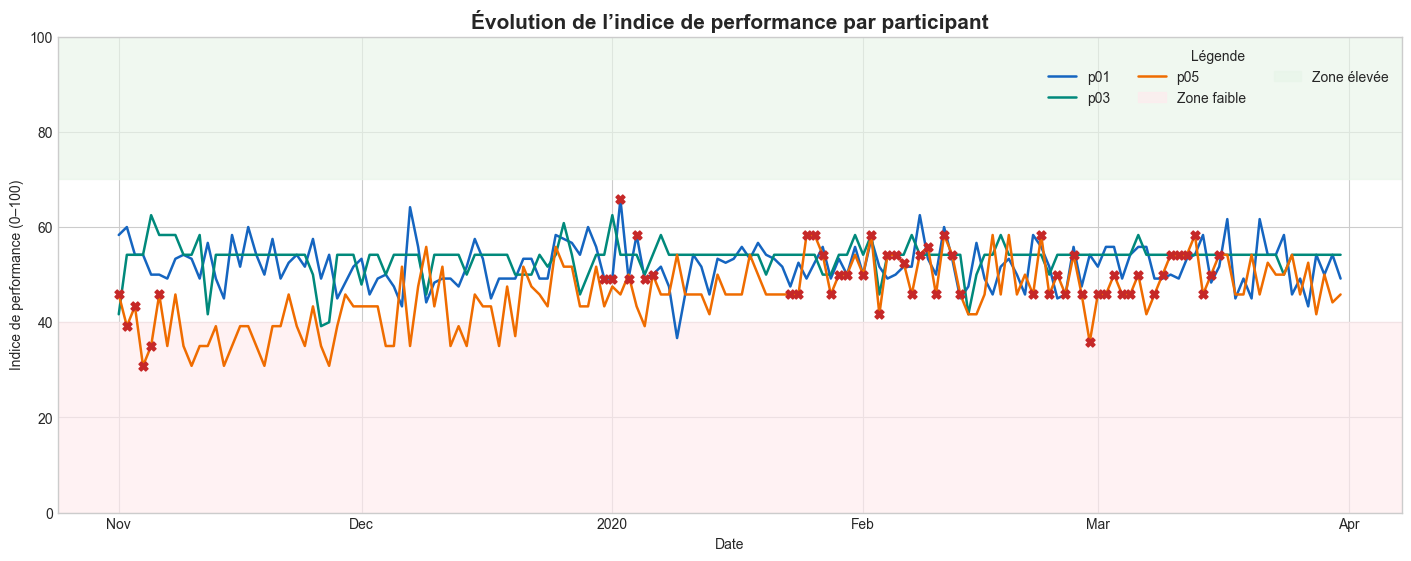

In [6]:
plot_df = df[df['date'].between('2019-11-01', '2020-03-31')].copy()
fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
for participant_id, group in plot_df.groupby('participant_id'):
    group = group.sort_values('date')
    ax.plot(group['date'], group['performance_index'], color=COLORS.get(participant_id, '#455A64'),
            linewidth=1.8, label=participant_id)
    injury_days = group[group['injury_next_7d'].eq(1)]
    ax.scatter(injury_days['date'], injury_days['performance_index'],
               color='#C62828', marker='X', s=42, zorder=3)
ax.axhspan(0, 40, color='#FFEBEE', alpha=0.65, label='Zone faible')
ax.axhspan(70, 100, color='#E8F5E9', alpha=0.65, label='Zone élevée')
ax.set_title('Évolution de l’indice de performance par participant', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indice de performance (0–100)')
ax.set_ylim(0, 100)
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.legend(title='Légende', ncol=3, frameon=False)
plt.show()

## Justification de l'approche

L'indice de performance est un indicateur composite entre 0 et 100. Il combine la readiness (0–10), la qualité du sommeil, la durée du sommeil, l'humeur, la fatigue et les courbatures. Les dimensions de récupération sont cohérentes avec les travaux sur la charge d'entraînement et la récupération. Les pondérations sont égales pour rester interprétables et ne pas prétendre estimer des coefficients scientifiques avec seulement trois participants.

Le modèle prédit l'indice du lendemain à partir des informations disponibles le jour courant. Cela évite de réutiliser directement les variables qui composent l'indice observé le même jour et donne une cible prédictive temporelle.

Le modèle de blessure est évalué avec la précision, le rappel, le F1-score, le ROC-AUC et le PR-AUC. Le rappel est important pour limiter les blessures manquées; le PR-AUC est ajouté car les jours à risque sont minoritaires. La performance du lendemain est évaluée avec la MAE, la RMSE et le R². La séparation est chronologique : les 20 % de dates les plus récentes de chaque participant servent de test.

Références : Banister & Calvert (1980), *Planning for future performance: implications for long term training*; Foster et al. (2001), *A new approach to monitoring exercise training*; Gabbett (2016), *The training-injury prevention paradox*.

Limites : l'indice est un proxy exploratoire et non une mesure clinique; l'estimation calorique à partir des photos reste heuristique; les modèles ne doivent pas être utilisés pour prendre une décision médicale.

## Résultats des modèles

Les modèles utilisent une séparation chronologique : les 20 % de dates les plus récentes de chaque participant sont conservées pour le test.

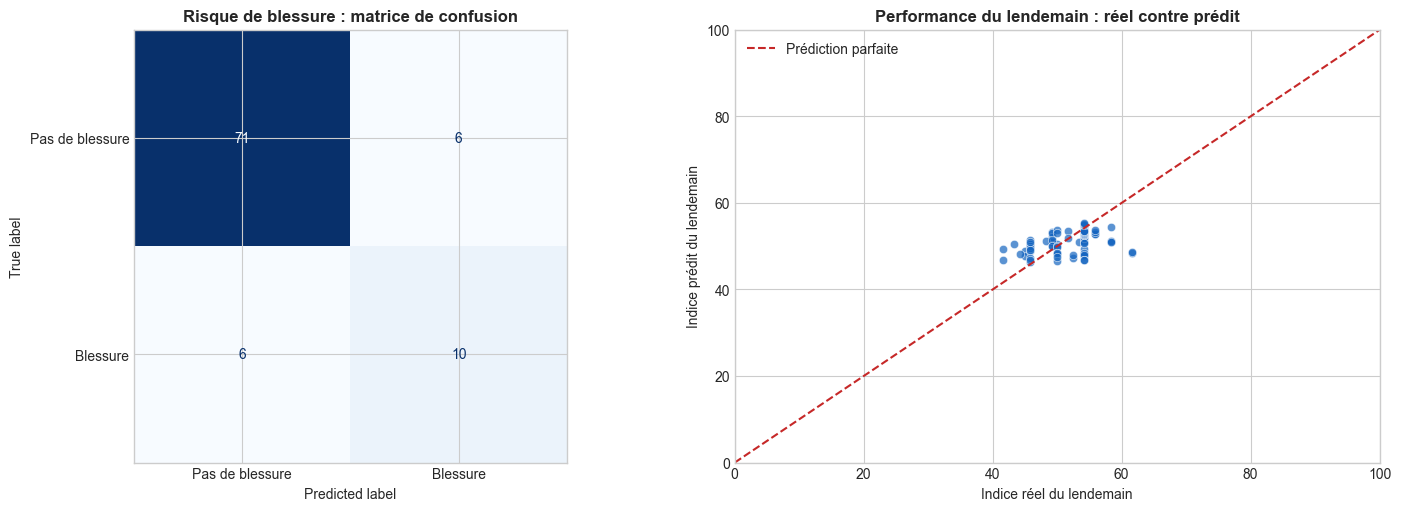

,valeur
Blessure - précision,0.625
Blessure - rappel,0.625
Blessure - F1,0.625
Blessure - ROC-AUC,0.933
Blessure - PR-AUC,0.743
Performance - MAE,2.870
Performance - RMSE,3.886
Performance - R²,0.132


,participant_id,date,injury_next_7d,injury_probability,performance_target,performance_prediction
0,p01,2020-02-29,0,0.069846,51.67,53.424549
1,p01,2020-03-01,0,0.052675,55.83,52.733671
2,p01,2020-03-02,0,0.051472,55.83,52.928608
3,p01,2020-03-03,0,0.188864,49.17,50.940395
4,p01,2020-03-04,0,0.031449,54.17,53.612572
5,p01,2020-03-05,0,0.025882,55.83,53.189063
6,p01,2020-03-06,0,0.161617,55.83,53.670111
7,p01,2020-03-07,0,0.066959,49.17,53.238179
8,p01,2020-03-08,0,0.100619,49.17,52.228284
9,p01,2020-03-09,0,0.130895,50.00,50.562001


In [ ]:
predictions_path = DATA_DIR / 'model_test_predictions.csv'
predictions = pd.read_csv(predictions_path, parse_dates=['date'])

y_true = predictions['injury_next_7d'].astype(int)
y_pred = predictions['injury_prediction'].astype(int)
injury_probability = predictions['injury_probability']
performance_target = predictions['performance_target']
performance_prediction = predictions['performance_prediction']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ConfusionMatrixDisplay(cm, display_labels=['Pas de blessure', 'Blessure']).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Risque de blessure : matrice de confusion', fontweight='bold')

axes[1].scatter(performance_target, performance_prediction,
                color='#1565C0', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[1].plot([0, 100], [0, 100], '--', color='#C62828', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_title('Performance du lendemain : réel contre prédit', fontweight='bold')
axes[1].set_xlabel('Indice réel du lendemain')
axes[1].set_ylabel('Indice prédit du lendemain')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].legend(frameon=False)
plt.show()

metrics = pd.Series({
    'Blessure - précision': precision_score(y_true, y_pred, zero_division=0),
    'Blessure - rappel': recall_score(y_true, y_pred, zero_division=0),
    'Blessure - F1': f1_score(y_true, y_pred, zero_division=0),
    'Blessure - ROC-AUC': roc_auc_score(y_true, injury_probability),
    'Blessure - PR-AUC': average_precision_score(y_true, injury_probability),
    'Performance - MAE': mean_absolute_error(performance_target, performance_prediction),
    'Performance - RMSE': mean_squared_error(performance_target, performance_prediction) ** 0.5,
    'Performance - R²': r2_score(performance_target, performance_prediction),
}).round(3)
display(metrics.to_frame('valeur'))
display(predictions[['participant_id', 'date', 'injury_next_7d', 'injury_probability',
                     'performance_target', 'performance_prediction']].head(10))